<a href="https://colab.research.google.com/github/kibwale/nipe_macho/blob/main/notebooks/testing_new_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Sun Jul 12 02:56:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import userdata
!pip install -q ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os

os.environ['KAGGLE_KEY'] =userdata.get("kaggleme")

!pip install -q kaggle
!kaggle datasets download -d ziedkelboussi/rdd2020-dataset -p /content/rdd2020 --unzip

Dataset URL: https://www.kaggle.com/datasets/ziedkelboussi/rdd2020-dataset
License(s): unknown
100% 1.38G/1.38G [00:09<00:00, 158MB/s]



In [4]:
import xml.etree.ElementTree as ET
import os
from pathlib import Path

DRIVE_ROOT = "/content/rdd2020"

# ---- Step 1: find all annotation folders (any 'xmls' dir under 'annotations') ----
def find_xml_dirs(root):
    xml_dirs = []
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == "xmls":
            xml_dirs.append(dirpath)
    return xml_dirs

# ---- Step 2: scan all XMLs once to build a consistent class list ----
def collect_classes(xml_dirs):
    classes = set()
    for xdir in xml_dirs:
        for xml_file in Path(xdir).glob("*.xml"):
            try:
                root = ET.parse(xml_file).getroot()
                for obj in root.findall("object"):
                    classes.add(obj.find("name").text)
            except ET.ParseError:
                print(f"Skipping malformed XML: {xml_file}")
    return sorted(classes)

# ---- Step 3: convert one xml file ----
def convert_annotation(xml_path, txt_path, classes):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)

    lines = []
    for obj in root.findall('object'):
        cls_name = obj.find('name').text
        if cls_name not in classes:
            continue
        cls_id = classes.index(cls_name)

        bbox = obj.find('bndbox')
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        w = (xmax - xmin) / img_w
        h = (ymax - ymin) / img_h

        lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

    with open(txt_path, 'w') as f:
        f.write("\n".join(lines))

# ---- Step 4: run over the whole tree ----
def convert_dataset(root):
    xml_dirs = find_xml_dirs(root)
    print(f"Found {len(xml_dirs)} annotation folders")

    classes = collect_classes(xml_dirs)
    print("Classes found:", classes)

    for xdir in xml_dirs:
        annotations_dir = os.path.dirname(xdir)          # .../annotations
        country_dir = os.path.dirname(annotations_dir)   # .../Japan (or Czech, India...)
        images_dir = os.path.join(country_dir, "images")
        labels_dir = os.path.join(country_dir, "labels")
        os.makedirs(labels_dir, exist_ok=True)

        xml_files = list(Path(xdir).glob("*.xml"))
        for xml_file in xml_files:
            txt_path = os.path.join(labels_dir, xml_file.stem + ".txt")
            try:
                convert_annotation(xml_file, txt_path, classes)
            except Exception as e:
                print(f"Error on {xml_file}: {e}")

        if os.path.isdir(images_dir):
            for img_file in Path(images_dir).glob("*.jpg"):
                txt_path = os.path.join(labels_dir, img_file.stem + ".txt")
                if not os.path.exists(txt_path):
                    open(txt_path, 'w').close()

        print(f"Converted {len(xml_files)} files in {country_dir}")

    return classes

classes = convert_dataset(DRIVE_ROOT)

with open(os.path.join(DRIVE_ROOT, "data.yaml"), "w") as f:
    f.write(f"train: {DRIVE_ROOT}/train/images\n")
    f.write(f"val: {DRIVE_ROOT}/test/images\n")
    f.write(f"nc: {len(classes)}\n")
    f.write(f"names: {classes}\n")

print("Done. Classes:", classes)

Found 3 annotation folders
Classes found: ['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']
Converted 10506 files in /content/rdd2020/train/Japan
Converted 2829 files in /content/rdd2020/train/Czech
Converted 7706 files in /content/rdd2020/train/India
Done. Classes: ['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']


In [5]:
for country in ["Japan", "Czech", "India"]:
    img_dir = Path(f"/content/rdd2020/train/{country}/images")
    lbl_dir = Path(f"/content/rdd2020/train/{country}/labels")
    n_img = len(list(img_dir.glob("*.jpg")))
    n_lbl = len(list(lbl_dir.glob("*.txt")))
    print(f"{country}: {n_img} images, {n_lbl} labels")

Japan: 10506 images, 10506 labels
Czech: 2829 images, 2829 labels
India: 7706 images, 7706 labels


In [6]:
import xml.etree.ElementTree as ET
import os
from pathlib import Path

DRIVE_ROOT = "/content/rdd2020"
TARGET_CLASSES = ["D40"]  # pothole only, becomes class 0

def find_xml_dirs(root):
    xml_dirs = []
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == "xmls":
            xml_dirs.append(dirpath)
    return xml_dirs

def convert_annotation(xml_path, txt_path, classes):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find('size')
    img_w = int(size.find('width').text)
    img_h = int(size.find('height').text)

    lines = []
    for obj in root.findall('object'):
        cls_name = obj.find('name').text
        if cls_name not in classes:
            continue  # drop non-pothole boxes
        cls_id = classes.index(cls_name)

        bbox = obj.find('bndbox')
        xmin = float(bbox.find('xmin').text)
        ymin = float(bbox.find('ymin').text)
        xmax = float(bbox.find('xmax').text)
        ymax = float(bbox.find('ymax').text)

        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        w = (xmax - xmin) / img_w
        h = (ymax - ymin) / img_h

        lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

    with open(txt_path, 'w') as f:
        f.write("\n".join(lines))

def convert_dataset(root, classes):
    xml_dirs = find_xml_dirs(root)
    print(f"Found {len(xml_dirs)} annotation folders")

    total_boxes = 0
    total_images_with_boxes = 0

    for xdir in xml_dirs:
        annotations_dir = os.path.dirname(xdir)
        country_dir = os.path.dirname(annotations_dir)
        images_dir = os.path.join(country_dir, "images")
        labels_dir = os.path.join(country_dir, "labels")
        os.makedirs(labels_dir, exist_ok=True)

        xml_files = list(Path(xdir).glob("*.xml"))
        for xml_file in xml_files:
            txt_path = os.path.join(labels_dir, xml_file.stem + ".txt")
            try:
                convert_annotation(xml_file, txt_path, classes)
                if os.path.getsize(txt_path) > 0:
                    total_images_with_boxes += 1
                    with open(txt_path) as f:
                        total_boxes += sum(1 for _ in f)
            except Exception as e:
                print(f"Error on {xml_file}: {e}")

        if os.path.isdir(images_dir):
            for img_file in Path(images_dir).glob("*.jpg"):
                txt_path = os.path.join(labels_dir, img_file.stem + ".txt")
                if not os.path.exists(txt_path):
                    open(txt_path, 'w').close()

        print(f"Converted {len(xml_files)} files in {country_dir}")

    print(f"\nTotal pothole boxes: {total_boxes}")
    print(f"Images containing at least one pothole: {total_images_with_boxes}")
    return classes

classes = convert_dataset(DRIVE_ROOT, TARGET_CLASSES)

with open(os.path.join(DRIVE_ROOT, "data.yaml"), "w") as f:
    f.write(f"train: {DRIVE_ROOT}/train/images\n")
    f.write(f"val: {DRIVE_ROOT}/test/images\n")
    f.write(f"nc: {len(classes)}\n")
    f.write(f"names: {classes}\n")

print("Done. Classes:", classes)

Found 3 annotation folders
Converted 10506 files in /content/rdd2020/train/Japan
Converted 2829 files in /content/rdd2020/train/Czech
Converted 7706 files in /content/rdd2020/train/India

Total pothole boxes: 5627
Images containing at least one pothole: 3074
Done. Classes: ['D40']


In [7]:
from pathlib import Path

for country in ["Japan", "Czech", "India"]:
    lbl_dir = Path(f"/content/rdd2020/train/{country}/labels")
    files = list(lbl_dir.glob("*.txt"))
    empty = sum(1 for f in files if f.stat().st_size == 0)
    nonempty = len(files) - empty
    print(f"{country}: {nonempty} with pothole, {empty} empty ({empty/len(files)*100:.1f}% empty)")

Japan: 1390 with pothole, 9116 empty (86.8% empty)
Czech: 154 with pothole, 2675 empty (94.6% empty)
India: 1530 with pothole, 6176 empty (80.1% empty)


In [8]:
import random

def subsample_negatives(country, keep_ratio=1.5):
    img_dir = Path(f"/content/rdd2020/train/{country}/images")
    lbl_dir = Path(f"/content/rdd2020/train/{country}/labels")

    pos_files = [f for f in lbl_dir.glob("*.txt") if f.stat().st_size > 0]
    neg_files = [f for f in lbl_dir.glob("*.txt") if f.stat().st_size == 0]

    n_keep = int(len(pos_files) * keep_ratio)
    n_keep = min(n_keep, len(neg_files))
    neg_to_drop = random.sample(neg_files, len(neg_files) - n_keep)

    for f in neg_to_drop:
        f.unlink()  # delete label file
        img_path = img_dir / f"{f.stem}.jpg"
        if img_path.exists():
            img_path.unlink()  # delete matching image

    print(f"{country}: kept {len(pos_files)} positive, {n_keep} negative, dropped {len(neg_to_drop)} negative")

for country in ["Japan", "Czech", "India"]:
    subsample_negatives(country, keep_ratio=1.5)

Japan: kept 1390 positive, 2085 negative, dropped 7031 negative
Czech: kept 154 positive, 231 negative, dropped 2444 negative
India: kept 1530 positive, 2295 negative, dropped 3881 negative


In [9]:
import shutil
import random
from pathlib import Path

DRIVE_ROOT = "/content/rdd2020"
VAL_RATIO = 0.15
random.seed(42)

# unified output dirs
final_train_img = Path(f"{DRIVE_ROOT}/final/train/images")
final_train_lbl = Path(f"{DRIVE_ROOT}/final/train/labels")
final_val_img = Path(f"{DRIVE_ROOT}/final/val/images")
final_val_lbl = Path(f"{DRIVE_ROOT}/final/val/labels")

for d in [final_train_img, final_train_lbl, final_val_img, final_val_lbl]:
    d.mkdir(parents=True, exist_ok=True)

def split_and_copy(country):
    img_dir = Path(f"{DRIVE_ROOT}/train/{country}/images")
    lbl_dir = Path(f"{DRIVE_ROOT}/train/{country}/labels")

    img_files = list(img_dir.glob("*.jpg"))
    random.shuffle(img_files)

    n_val = int(len(img_files) * VAL_RATIO)
    val_files = img_files[:n_val]
    train_files = img_files[n_val:]

    for f in train_files:
        shutil.copy(f, final_train_img / f"{country}_{f.name}")
        lbl = lbl_dir / f"{f.stem}.txt"
        shutil.copy(lbl, final_train_lbl / f"{country}_{f.stem}.txt")

    for f in val_files:
        shutil.copy(f, final_val_img / f"{country}_{f.name}")
        lbl = lbl_dir / f"{f.stem}.txt"
        shutil.copy(lbl, final_val_lbl / f"{country}_{f.stem}.txt")

    print(f"{country}: {len(train_files)} train, {len(val_files)} val")

for country in ["Japan", "Czech", "India"]:
    split_and_copy(country)

# rewrite data.yaml pointing to unified folders
with open(f"{DRIVE_ROOT}/final/data.yaml", "w") as f:
    f.write(f"train: {DRIVE_ROOT}/final/train/images\n")
    f.write(f"val: {DRIVE_ROOT}/final/val/images\n")
    f.write(f"nc: 1\n")
    f.write(f"names: ['D40']\n")

print("Done. data.yaml written to", f"{DRIVE_ROOT}/final/data.yaml")

Japan: 2954 train, 521 val
Czech: 328 train, 57 val
India: 3252 train, 573 val
Done. data.yaml written to /content/rdd2020/final/data.yaml


In [10]:
!pip install roboflow
from roboflow import Roboflow


api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 76.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov8:: 100%|██████████| 527/527 [00:00<00:00, 7682.06it/s]


Total pothole boxes: 5627
Width  (% of image): mean=13.9%, min=1.7%, max=99.7%
Height (% of image): mean=8.2%, min=1.2%, max=59.3%
Area   (% of image): mean=1.7%, min=0.0%, max=38.7%

Small boxes (<1% area):  3631 (64.5%)
Medium boxes (1-9%):     1789 (31.8%)
Large boxes (>9%):       207 (3.7%)


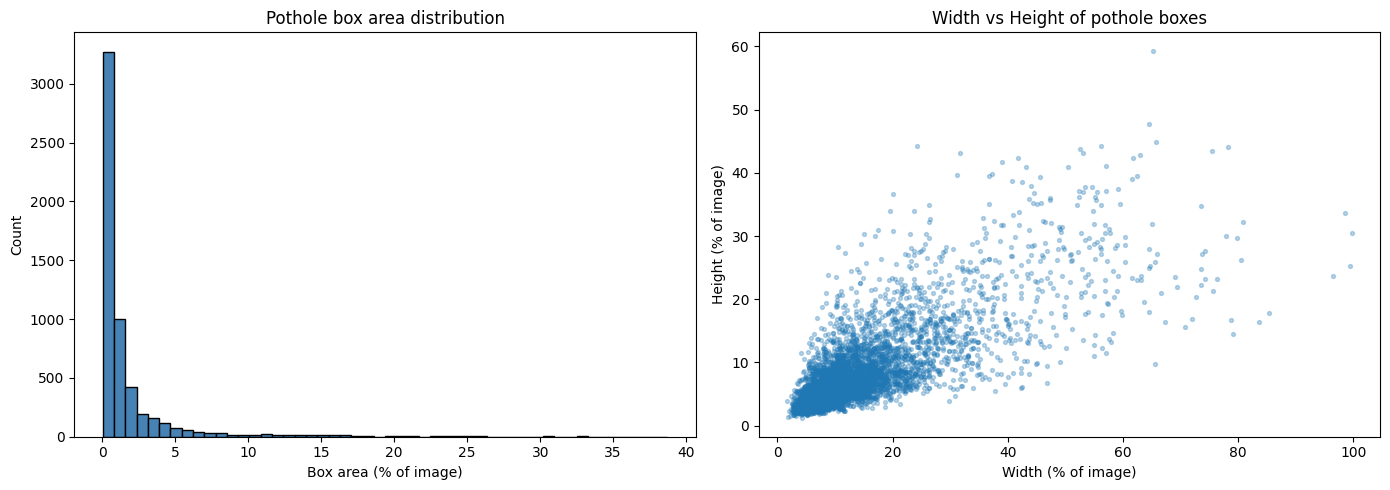

In [11]:
import matplotlib.pyplot as plt
from pathlib import Path

DRIVE_ROOT = "/content/rdd2020"

sizes = []  # (width_pct, height_pct, area_pct) per box
countries_list = []

for country in ["Japan", "Czech", "India"]:
    lbl_dir = Path(f"{DRIVE_ROOT}/train/{country}/labels")
    for f in lbl_dir.glob("*.txt"):
        with open(f) as fh:
            for line in fh:
                parts = line.split()
                if len(parts) != 5:
                    continue
                _, xc, yc, w, h = map(float, parts)
                sizes.append((w * 100, h * 100, w * h * 100))
                countries_list.append(country)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
areas = [s[2] for s in sizes]

print(f"Total pothole boxes: {len(sizes)}")
print(f"Width  (% of image): mean={sum(widths)/len(widths):.1f}%, min={min(widths):.1f}%, max={max(widths):.1f}%")
print(f"Height (% of image): mean={sum(heights)/len(heights):.1f}%, min={min(heights):.1f}%, max={max(heights):.1f}%")
print(f"Area   (% of image): mean={sum(areas)/len(areas):.1f}%, min={min(areas):.1f}%, max={max(areas):.1f}%")

# COCO-style small/medium/large thresholds, adapted as area % of image
# small: <1% area, medium: 1-9%, large: >9%  (rough proxy, not exact COCO pixel thresholds)
small = sum(1 for a in areas if a < 1)
medium = sum(1 for a in areas if 1 <= a < 9)
large = sum(1 for a in areas if a >= 9)

print(f"\nSmall boxes (<1% area):  {small} ({small/len(areas)*100:.1f}%)")
print(f"Medium boxes (1-9%):     {medium} ({medium/len(areas)*100:.1f}%)")
print(f"Large boxes (>9%):       {large} ({large/len(areas)*100:.1f}%)")

# histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(areas, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel("Box area (% of image)")
axes[0].set_ylabel("Count")
axes[0].set_title("Pothole box area distribution")

axes[1].scatter(widths, heights, alpha=0.3, s=8)
axes[1].set_xlabel("Width (% of image)")
axes[1].set_ylabel("Height (% of image)")
axes[1].set_title("Width vs Height of pothole boxes")
plt.tight_layout()
plt.show()

In [12]:
!cat {dataset.location}/data.yaml

names:
- potholes
nc: 1
roboflow:
  license: CC BY 4.0
  project: chepalungu
  url: https://universe.roboflow.com/nipemacho/chepalungu/dataset/1
  version: 1
  workspace: nipemacho
test: ../test/images
train: ../train/images
val: ../valid/images


In [13]:
import shutil
from pathlib import Path

ROBOFLOW_ROOT = Path(dataset.location)

def copy_roboflow_split(rf_split_name, target_split_name):
    src_img = ROBOFLOW_ROOT / rf_split_name / "images"
    src_lbl = ROBOFLOW_ROOT / rf_split_name / "labels"

    dst_img = Path(f"{DRIVE_ROOT}/final/{target_split_name}/images")
    dst_lbl = Path(f"{DRIVE_ROOT}/final/{target_split_name}/labels")
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    count = 0
    for img_file in src_img.glob("*"):
        lbl_file = src_lbl / f"{img_file.stem}.txt"
        if not lbl_file.exists():
            continue
        shutil.copy(img_file, dst_img / f"Kenya_{img_file.name}")
        shutil.copy(lbl_file, dst_lbl / f"Kenya_{img_file.stem}.txt")
        count += 1
    print(f"Kenya {rf_split_name} -> {target_split_name}: {count} images")

copy_roboflow_split("train", "train")
copy_roboflow_split("valid", "val")
copy_roboflow_split("test", "test")  # optional, keep if you want a separate held-out set

Kenya train -> train: 183 images
Kenya valid -> val: 52 images
Kenya test -> test: 26 images


Total pothole boxes (final dataset): 5627
Width  (% of image): mean=13.9%, min=1.7%, max=99.7%
Height (% of image): mean=8.2%, min=1.2%, max=59.3%
Area   (% of image): mean=1.7%, min=0.0%, max=38.7%

Small boxes (<1% area):  3631 (64.5%)
Medium boxes (1-9%):     1789 (31.8%)
Large boxes (>9%):       207 (3.7%)

--- Per-country box counts and mean area ---
India: 3187 boxes, mean area=2.29%, small=54.2%
Japan: 2243 boxes, mean area=0.93%, small=77.4%
Czech: 197 boxes, mean area=0.58%, small=85.8%


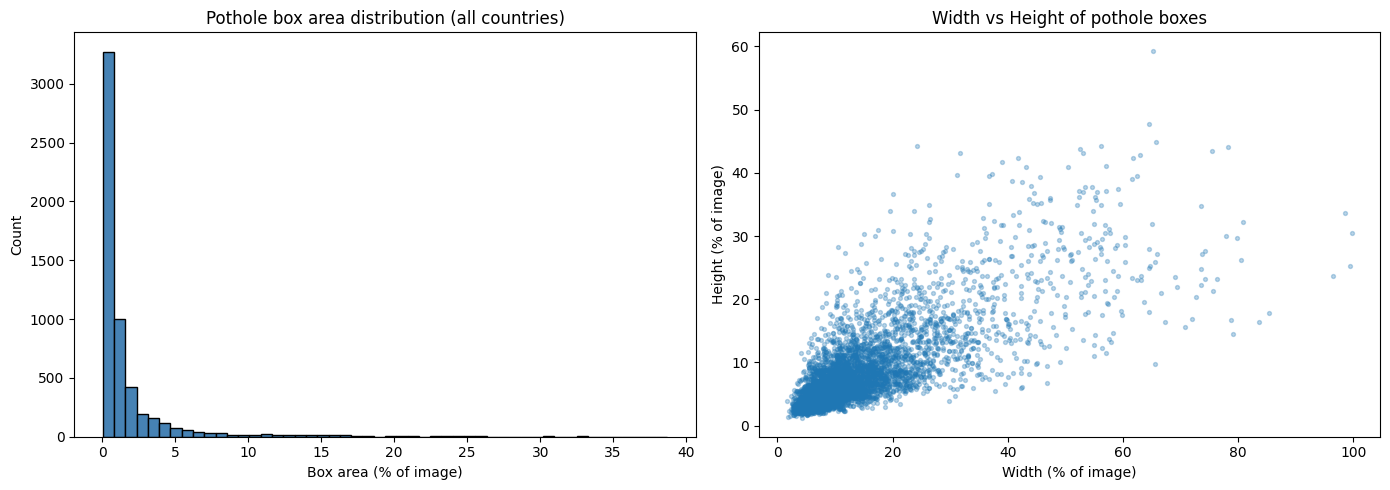

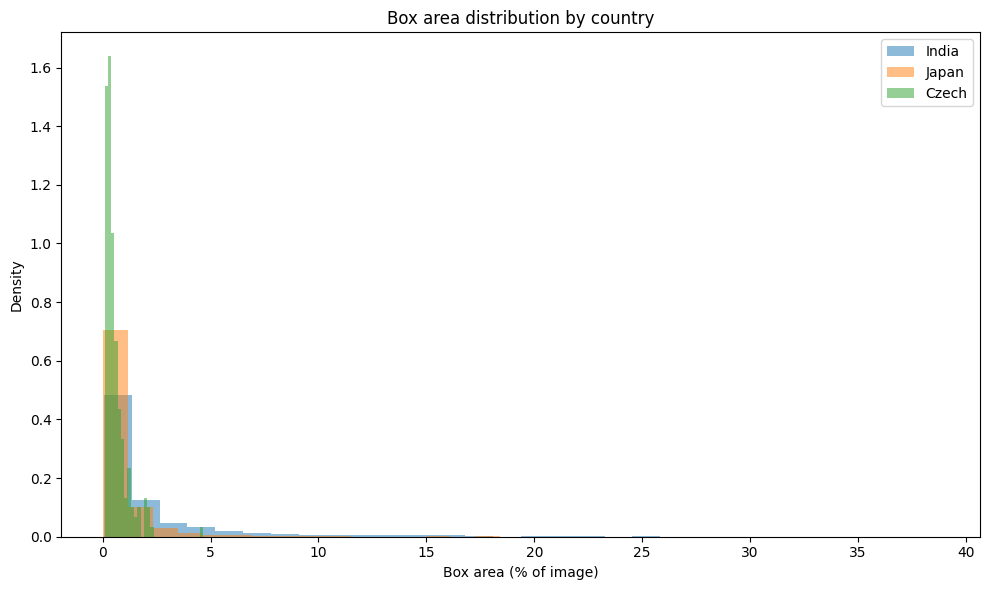

In [14]:
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

DRIVE_ROOT = "/content/rdd2020"

sizes = []          # (width_pct, height_pct, area_pct) per box
countries_list = []  # matching country label per box

def get_country(filename):
    # filenames are prefixed like Japan_..., Czech_..., India_..., Kenya_...
    for c in ["Japan", "Czech", "India", "Kenya"]:
        if filename.startswith(c + "_"):
            return c
    return "Unknown"

for split in ["train", "val"]:
    lbl_dir = Path(f"{DRIVE_ROOT}/final/{split}/labels")
    if not lbl_dir.exists():
        continue
    for f in lbl_dir.glob("*.txt"):
        country = get_country(f.name)
        with open(f) as fh:
            for line in fh:
                parts = line.split()
                if len(parts) != 5:
                    continue
                _, xc, yc, w, h = map(float, parts)
                sizes.append((w * 100, h * 100, w * h * 100))
                countries_list.append(country)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
areas = [s[2] for s in sizes]

print(f"Total pothole boxes (final dataset): {len(sizes)}")
print(f"Width  (% of image): mean={sum(widths)/len(widths):.1f}%, min={min(widths):.1f}%, max={max(widths):.1f}%")
print(f"Height (% of image): mean={sum(heights)/len(heights):.1f}%, min={min(heights):.1f}%, max={max(heights):.1f}%")
print(f"Area   (% of image): mean={sum(areas)/len(areas):.1f}%, min={min(areas):.1f}%, max={max(areas):.1f}%")

small = sum(1 for a in areas if a < 1)
medium = sum(1 for a in areas if 1 <= a < 9)
large = sum(1 for a in areas if a >= 9)

print(f"\nSmall boxes (<1% area):  {small} ({small/len(areas)*100:.1f}%)")
print(f"Medium boxes (1-9%):     {medium} ({medium/len(areas)*100:.1f}%)")
print(f"Large boxes (>9%):       {large} ({large/len(areas)*100:.1f}%)")

# Per-country breakdown
print("\n--- Per-country box counts and mean area ---")
by_country = defaultdict(list)
for c, a in zip(countries_list, areas):
    by_country[c].append(a)

for c, vals in by_country.items():
    print(f"{c}: {len(vals)} boxes, mean area={sum(vals)/len(vals):.2f}%, "
          f"small={sum(1 for v in vals if v<1)/len(vals)*100:.1f}%")

# Overall histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(areas, bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel("Box area (% of image)")
axes[0].set_ylabel("Count")
axes[0].set_title("Pothole box area distribution (all countries)")

axes[1].scatter(widths, heights, alpha=0.3, s=8)
axes[1].set_xlabel("Width (% of image)")
axes[1].set_ylabel("Height (% of image)")
axes[1].set_title("Width vs Height of pothole boxes")
plt.tight_layout()
plt.show()

# Per-country area histograms, overlaid
fig, ax = plt.subplots(figsize=(10, 6))
for c, vals in by_country.items():
    ax.hist(vals, bins=30, alpha=0.5, label=c, density=True)
ax.set_xlabel("Box area (% of image)")
ax.set_ylabel("Density")
ax.set_title("Box area distribution by country")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
from pathlib import Path

def polygon_to_bbox(parts):
    cls = parts[0]
    coords = list(map(float, parts[1:]))
    xs = coords[0::2]
    ys = coords[1::2]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    w = x_max - x_min
    h = y_max - y_min
    return f"{cls} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"

def fix_split(split):
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    fixed_count = 0
    total_converted = 0

    for f in lbl_dir.glob("Kenya_*.txt"):
        if f.stat().st_size == 0:
            continue
        lines = f.read_text().strip().split("\n")
        new_lines = []
        changed = False
        for line in lines:
            parts = line.split()
            if not parts:
                continue
            if len(parts) == 5:
                new_lines.append(line)
            elif len(parts) >= 7 and len(parts) % 2 == 1:
                new_lines.append(polygon_to_bbox(parts))
                changed = True
                total_converted += 1
        if changed:
            f.write_text("\n".join(new_lines))
            fixed_count += 1

    print(f"{split}: fixed {fixed_count} files, converted {total_converted} polygon lines to boxes")

fix_split("train")
fix_split("val")

train: fixed 132 files, converted 344 polygon lines to boxes
val: fixed 38 files, converted 99 polygon lines to boxes


In [36]:
from pathlib import Path

for split in ["train", "val"]:
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    all_files = list(lbl_dir.glob("*.txt"))
    kenya_files = [f for f in all_files if "kenya" in f.name.lower()]
    print(f"{split}: {len(all_files)} total label files, {len(kenya_files)} contain 'kenya' (any case)")
    print("Sample filenames:", [f.name for f in all_files[:5]])

train: 6717 total label files, 183 contain 'kenya' (any case)
Sample filenames: ['India_India_000399.txt', 'Japan_Japan_008208.txt', 'India_India_005978.txt', 'Japan_Japan_003878.txt', 'Japan_Japan_010422.txt']
val: 1203 total label files, 52 contain 'kenya' (any case)
Sample filenames: ['India_India_006283.txt', 'Japan_Japan_006393.txt', 'Kenya_IMG_20241223_124948_jpg.rf.54069f822e2b46382d27833f0f763012.txt', 'India_India_000835.txt', 'Czech_Czech_002866.txt']


In [37]:
from pathlib import Path

lbl_dir = Path("/content/rdd2020/final/train/labels")
kenya_files = [f for f in lbl_dir.glob("*.txt") if "kenya" in f.name.lower()]
print(kenya_files[:5])

[PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_132930_jpg.rf.ff655e11a27d906037b5e0d25d0222e3.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_132203_jpg.rf.5aef933190b50c53902c00e48db88cd5.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_134228_jpg.rf.873f39edb73aff776ea608a40620cc90.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_125234_jpg.rf.8a2ca0367324e66c7bba7fa9b9d3b60a.txt'), PosixPath('/content/rdd2020/final/train/labels/Kenya_IMG_20241223_125459_jpg.rf.43d94f0d8f1876cb8ba3667388fd5259.txt')]


In [38]:
from pathlib import Path

for split in ["train", "val"]:
    img_dir = Path(f"/content/rdd2020/final/{split}/images")
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")

    img_stems = {f.stem for f in img_dir.glob("*")}
    lbl_stems = {f.stem for f in lbl_dir.glob("*.txt")}

    missing_labels = img_stems - lbl_stems
    orphaned_labels = lbl_stems - img_stems

    print(f"{split}: {len(img_stems)} images, {len(lbl_stems)} labels")
    print(f"  Missing labels: {len(missing_labels)}")
    print(f"  Orphaned labels: {len(orphaned_labels)}")

train: 6717 images, 6717 labels
  Missing labels: 0
  Orphaned labels: 0
val: 1203 images, 1203 labels
  Missing labels: 0
  Orphaned labels: 0


In [39]:
bad_files = []
for split in ["train", "val"]:
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    for f in lbl_dir.glob("*.txt"):
        with open(f) as fh:
            for i, line in enumerate(fh):
                parts = line.split()
                if len(parts) != 5:
                    bad_files.append((f, i, "wrong number of fields"))
                    continue
                cls, xc, yc, w, h = parts
                if int(cls) != 0:
                    bad_files.append((f, i, f"unexpected class id {cls}"))
                vals = [float(xc), float(yc), float(w), float(h)]
                if any(v < 0 or v > 1 for v in vals):
                    bad_files.append((f, i, "coordinate out of [0,1] range"))

print(f"Found {len(bad_files)} problematic label lines")
for f, i, reason in bad_files[:20]:
    print(f, i, reason)

Found 0 problematic label lines


In [19]:
!cat "/content/rdd2020/final/train/labels/Kenya_IMG_20241223_125459_jpg.rf.43d94f0d8f1876cb8ba3667388fd5259.txt"

0 0.456617646875 0.5569661453125 0.459068628125 0.556640625 0.459803921875 0.5537109375 0.4588235296875 0.5514322921875 0.4544117640625 0.5501302078125 0.4318627453125 0.548828125 0.40833333281249995 0.5524088546875 0.40857843125000004 0.5572916671875 0.4134803921875 0.5589192703125 0.439460784375 0.55859375 0.456617646875 0.5569661453125
0 0.5004901953124999 0.5250651046875 0.502696078125 0.5231119796875 0.5017156859375 0.5205078125 0.4977941171875 0.5201822921875 0.49411764687500004 0.5182291671875 0.4620098046875 0.5182291671875 0.448039215625 0.5211588546875 0.45171568593750006 0.5234375 0.46421568593750007 0.5244140625 0.4872549015625 0.5234375 0.5004901953124999 0.5250651046875
0 0.326225490625 0.5237630203125 0.3357843140625 0.5211588546875 0.334068628125 0.5182291671875 0.331617646875 0.517578125 0.31323529375 0.5182291671875 0.30392156875 0.5205078125 0.303431371875 0.521484375 0.3049019609375 0.5227864578125 0.3115196078125 0.5237630203125 0.326225490625 0.5237630203125
0 0.4

In [40]:
from pathlib import Path

def is_valid_label_line(parts):
    if len(parts) == 5:
        return True  # standard box format
    if len(parts) >= 7 and len(parts) % 2 == 1:
        return True  # polygon format: class + even number of x,y pairs
    return False

bad_files = []
for split in ["train", "val"]:
    lbl_dir = Path(f"/content/rdd2020/final/{split}/labels")
    for f in lbl_dir.glob("*.txt"):
        with open(f) as fh:
            for i, line in enumerate(fh):
                parts = line.split()
                if not parts:
                    continue
                if not is_valid_label_line(parts):
                    bad_files.append((f, i, f"{len(parts)} fields"))

print(f"Found {len(bad_files)} genuinely problematic label lines")
for f, i, reason in bad_files[:20]:
    print(f, i, reason)

Found 0 genuinely problematic label lines


In [41]:
import hashlib

def file_hash(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()

train_hashes = {file_hash(f): f for f in Path("/content/rdd2020/final/train/images").glob("*")}
val_hashes = {file_hash(f): f for f in Path("/content/rdd2020/final/val/images").glob("*")}

overlap = set(train_hashes) & set(val_hashes)
print(f"Duplicate images between train and val: {len(overlap)}")
for h in list(overlap)[:10]:
    print(train_hashes[h], val_hashes[h])

Duplicate images between train and val: 0


In [22]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
model.train(
    data="/content/rdd2020/final/data.yaml",
    imgsz=640,
    epochs=100,
    batch=-1,
    patience=25,
    seed=42,
    name="baseline_s_640",
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2020/final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_s_640, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783e759617c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [25]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

os.makedirs("/content/drive/MyDrive/potholes/runs", exist_ok=True)

# adjust source path to match what step 1 showed you
shutil.copytree(
    "/content/runs/detect/baseline_s_640/",   # your actual run folder
    "/content/drive/MyDrive/potholes/runs/train_backup",
    dirs_exist_ok=True
)

print("Copied to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to Drive


In [24]:
!find /content/runs -name "best.pt"

/content/runs/detect/baseline_s_640/weights/best.pt


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = "/content/runs/detect/baseline_s_640/results.csv"
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()  # Ultralytics sometimes leaves leading spaces in column names

print(df.columns.tolist())  # confirm exact column names before plotting

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


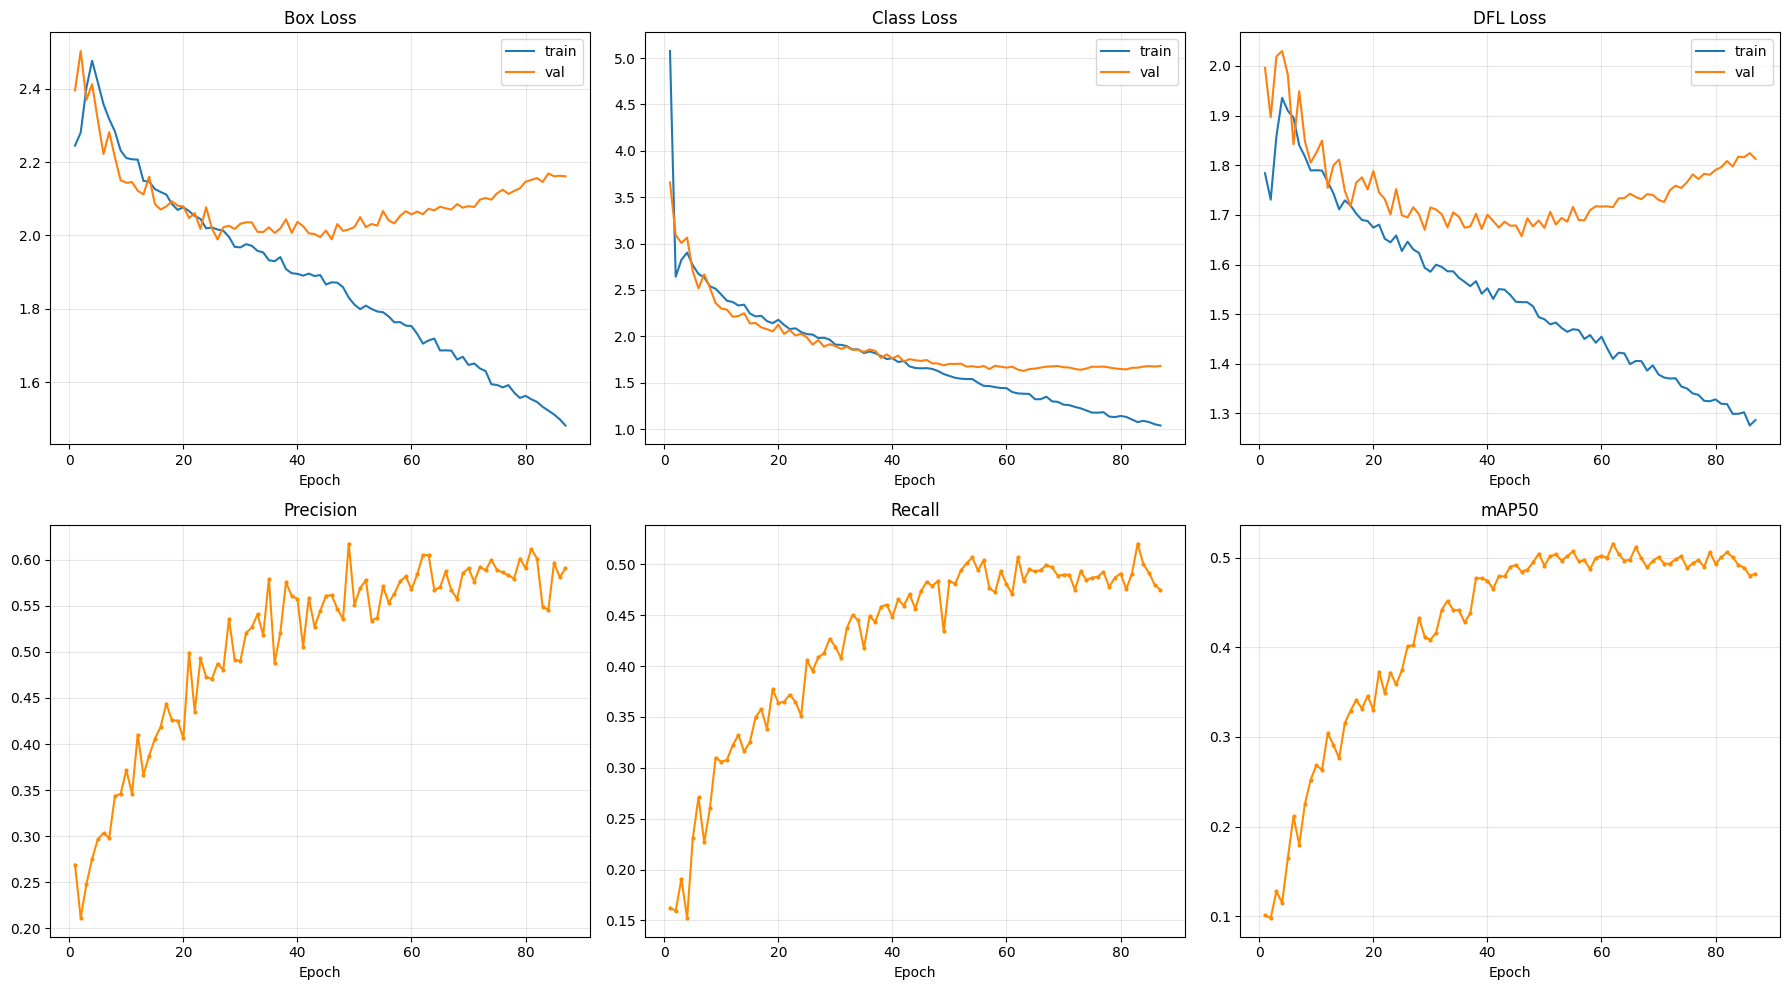

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: train vs val loss pairs
loss_pairs = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]

for ax, (train_col, val_col, title) in zip(axes[0], loss_pairs):
    if train_col in df.columns and val_col in df.columns:
        ax.plot(df["epoch"], df[train_col], label="train")
        ax.plot(df["epoch"], df[val_col], label="val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.set_visible(False)

# Row 2: precision, recall, mAP metrics
metrics = [
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)", "Recall"),
    ("metrics/mAP50(B)", "mAP50"),
]

for ax, (col, title) in zip(axes[1], metrics):
    if col in df.columns:
        ax.plot(df["epoch"], df[col], color="darkorange", marker='o', markersize=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/potholes/runs/s_960-2/weights/last.pt")
model.train(resume=True)

In [ ]:
model = YOLO("yolov8s.pt")
model.train(
    data="/content/rdd2020/final/data.yaml",
    imgsz=960,
    epochs=70,
    batch=-1,
    patience=20,
    seed=42,
    project="/content/drive/MyDrive/potholes/runs",  # saves here instead of /content/runs
    name="s_960",
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rdd2020/final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=s_960-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [16]:
model = YOLO("yolov8s.pt")
model.train(
    data="data.yaml",
    imgsz=960,
    epochs=100,
    batch=-1,              # auto-batch for available VRAM
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    box=9.0,
    scale=0.3,
    copy_paste=0.2,
    mosaic=0.6,
    close_mosaic=15,
    patience=25,
    seed=42,
)

NameError: name 'YOLO' is not defined

In [ ]:
#!pip install --quiet "numpy==1.26.4" "pandas==2.2.2" "ultralytics==8.2.103" "roboflow" 2>/dev/null
# Restart the Colab runtime automatically so the new Numpy takes effect

#import os
#os.kill(os.getpid(), 9)

#!pip uninstall -y numpy pandas
#!pip install numpy==1.26.4
#!pip install pandas==2.2.2
#!pip install ultralytics==8.2.103 -q

#!pip install roboflow
# Import common data science libraries
#import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image
from google.colab import userdata
from roboflow import Roboflow
import os
import glob
import random


# Import the Fynesse framework
#import fynesse
#from fynesse import access, assess, address

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.1/875.1 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 70.3 MB/s eta 0:00:00


In [ ]:

# @title fynesse(not currently used)
#### Cloning the Project Repository To utilize our custom Python modules and keep our project organized, we need to pull the latest version of our project repository into the Colab environment.The following cell performs a fresh clone by first removing any outdated versions of the folder, downloading the latest code from GitHub, and appending the repository to our system path so we can easily import our custom scripts.
# Remove existing repository folder to ensure a clean clone and setup
#import shutil
#shutil.rmtree("/content/nipe_macho", ignore_errors=True)
# Clone the latest version of the repository from GitHub

#!git clone https://github.com/silprosa/nipe_macho.git
#import os, subprocess, importlib, sys
#sys.path.append("/content/nipe_macho")

## 2. Initializing the YOLOv8 Base Model
Before we train the AI on our custom pothole dataset, we need to initialize a foundational model.

Instead of training a neural network completely from scratch—which requires massive amounts of time and data—we use **Transfer Learning**. In this cell, we load `yolov8n.pt` (the lightweight "Nano" version of YOLOv8), which has already been pre-trained on the massive COCO dataset. Because it already recognizes basic edges, shapes, and generic objects, it will learn to identify potholes much faster.


The Nano architecture was chosen specifically to balance high accuracy with fast, real-time inference speeds suitable for edge devices.

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 89.3MB/s]


A deeper dive into the YOLOv8 architecture and its capabilities can be found in the official [Ultralytics documentation](https://docs.ultralytics.com/models/yolov8#yolov8-usage-examples).

In [ ]:
model.info()

YOLOv8n summary: 225 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs


(225, 3157200, 0, 8.8575488)

---

## 3. Data Acquisition


Instead of hardcoding our private Roboflow API key directly into the notebook—which poses a severe security risk if the notebook is ever shared or committed to GitHub—we utilize Google Colab's built-in **Secrets** manager.

*To run this cell successfully, click the 🔑 Secrets icon on the left sidebar of Colab, add a new secret named `roboflow_api`, and paste your Roboflow API key as the value. Ensure the "Notebook access" toggle is turned on.*

In [ ]:
# safely retrieve our secret value
api_key = userdata.get('roboflow_api')
rf = Roboflow(api_key=api_key)

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "/content/data"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ziedkelboussi/rdd2020-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_597/2856089825.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


ValueError: Unsupported file extension: ''. Supported file extensions are: .csv, .tsv, .json, .jsonl, .xml, .parquet, .feather, .sqlite, .sqlite3, .db, .db3, .s3db, .dl3, .xls, .xlsx, .xlsm, .xlsb, .odf, .ods, .odt

### Fetching the Chepalungu Dataset
Using our authenticated Roboflow connection, we define our specific target directory. We navigate to the `nipemacho` workspace and select the `chepalungu` project.

The following cell downloads version 1 of our annotated pothole dataset into Colab, specifying 'yolov8' as the export format.
This formats the dataset and annotations into normalized text files compatible with YOLO architecture.

In [ ]:
project = rf.workspace("nipemacho").project("chepalungu")
dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to chepalungu-1 in yolov8:: 100%|██████████| 527/527 [00:00<00:00, 5131.30it/s]


In [ ]:
print(dataset.location) # Prints the local directory where the dataset is downloaded

/content/chepalungu-1


## Phase 2: Assess (Dataset Verification)

During the annotation and export phase (via Roboflow), our dataset was automatically divided into three distinct splits: **train**, **valid** (validation), and **test**.

YOLO formats its annotations as `.txt` files containing normalized coordinates alongside these images. Before we begin training, we must perform a quick sanity check to ensure these folders were downloaded correctly and contain the expected number of images.

*(Note: We don't need to manually verify the bounding box coordinates or background images here, as the YOLOv8 training algorithm automatically performs a deep scan and summarizes dataset health before the first epoch begins).*

In [ ]:
import os

# Do a simple count of the files in the training folder
train_dir = f"{dataset.location}/train/images"
image_count = len(os.listdir(train_dir))

print(f"Found {image_count} images in the training folder.")

Found 183 images in the training folder.


## 4. Model Training

With our dataset verified and our hardware configured, we initiate the training sequence.

We are training the **YOLOv8s (Small)** architecture for 25 epochs. We have explicitly set the image size (`imgsz`) to 800 pixels (larger than the default 640) to preserve the resolution of smaller, distant road defects. Additionally, setting `plots=True` ensures the system automatically generates evaluation metrics, loss curves, and confusion matrices upon completion.

In [ ]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=25 imgsz=800 plots=True

100% 21.5M/21.5M [00:00<00:00, 209MB/s]
New https://pypi.org/project/ultralytics/8.4.82 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/chepalungu-1/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, reti

## 5. Model Evaluation

Once training is complete, we must evaluate the model's performance to ensure it has converged correctly and is not overfitting.


#### Locating the Model Weights and Results
When YOLOv8 completes a training run, it automatically generates a directory to save all outputs, including the finalized model weights (`best.pt`), evaluation charts, and validation predictions.

By default, Ultralytics structures this path as `runs/[task]/[mode]`. Since we performed object **detection** in **training** mode, our initial results are saved to `runs/detect/train`.

*(Note: If you run the training cell multiple times, YOLO will automatically create new folders sequentially, such as `train2`, `train3`, etc. to prevent overwriting your previous work. Ensure this path points to your most recent successful run).*

In [31]:
# Define the results directory
results_dir = '/content/runs/detect/baseline_s_640'

YOLOv8 automatically generates comprehensive evaluation metrics during the training process. In the cell below, we extract and visualize:
1. **Training Metrics (`results.png`):** A graphical overview of the Loss curves, Precision, Recall, and mAP across all 25 epochs.


In [32]:
# 1. Display results plot (loss and metrics over epochs)
results_plot = f'{results_dir}/results.png'

if os.path.exists(results_plot):
    print("--- Training Metrics ---")
    display(Image(filename=results_plot, width=800))
else:
    print("results.png not found in the specified directory.")

--- Training Metrics ---


NameError: name 'Image' is not defined

3. **Validation Batches:** Visual overlays of the model's predictions on the unseen validation dataset to physically confirm bounding box accuracy

In [30]:
# 3. Display validation predictions
print("--- Validation Predictions ---")
found_images = False

for i in range(10):
    pred_path = f'{results_dir}/val_batch{i}_pred.jpg'
    if os.path.exists(pred_path):
        display(Image(filename=pred_path, width=800))
        found_images = True

if not found_images:
    print("No validation prediction batches (val_batchX_pred.jpg) found.")

--- Validation Predictions ---


NameError: name 'results_dir' is not defined

2. **Confusion Matrix (`confusion_matrix.png`):** To visualize the ratio of True Positives (correct detections) to False Positives (background mistakenly identified as a pothole).

In [33]:
# 2. Display confusion matrix
confusion_matrix = f'{results_dir}/confusion_matrix.png'

if os.path.exists(confusion_matrix):
    print("--- Confusion Matrix ---")
    display(Image(filename=confusion_matrix, width=600))
else:
    print("confusion_matrix.png not found in the specified directory.")

--- Confusion Matrix ---


NameError: name 'Image' is not defined

### Data Quality Visualization



---


## 6. Inference on Unseen Data

The ultimate test of an object detection model is its performance on data it has never seen before.

In this final section, we load our newly trained custom weights (`best.pt`) and run inference on the **Test** dataset. We set a confidence threshold of `0.25`, meaning the model will only draw a bounding box if it is at least 25% confident that the detected object is a pothole. Finally, we randomly sample and display the resulting images to visually verify the model's predictive accuracy.

In [34]:


# 1. Load the newly trained custom weights
# (Using the latest_run variable from Section 5 ensures we get the right folder)
best_weights = os.path.join(results_dir, 'weights', 'best.pt')
model = YOLO(best_weights)

# 2. Define the path to the unseen test images using our dynamic variable
test_images_path = f"{dataset.location}/test/images"

# 3. Run inference!
# save=True generates the annotated images
# conf=0.25 sets the confidence threshold
print(f"Running predictions on: {test_images_path}")
results = model.predict(source=test_images_path, save=True, conf=0.25)

# 4. Display a few random predictions
# YOLO saves new predictions in a sequentially numbered 'predict' folder.
# We find the most recent one to ensure we are looking at the latest results.
predict_dirs = glob.glob('runs/detect/predict*')

if predict_dirs:
    latest_predict = max(predict_dirs, key=os.path.getmtime)
    predicted_images = glob.glob(f'{latest_predict}/*.jpg')

    if predicted_images:
        print(f"\n✅ --- Displaying Random Predictions from {latest_predict} ---")
        # Select up to 3 random images
        sample_images = random.sample(predicted_images, min(3, len(predicted_images)))
        for img_path in sample_images:
            display(Image(filename=img_path, width=800))
    else:
        print("No predicted images found inside the prediction folder.")
else:
    print("No prediction directory found. Check if model.predict() succeeded.")

Running predictions on: /content/chepalungu-1/test/images

image 1/26 /content/chepalungu-1/test/images/IMG_20241223_124318_jpg.rf.2a7165695765e7435a7d2a251f6ca041.jpg: 640x640 (no detections), 16.2ms
image 2/26 /content/chepalungu-1/test/images/IMG_20241223_124512_jpg.rf.3f09f5cf532a0931c69233607209b71a.jpg: 640x640 4 D40s, 16.2ms
image 3/26 /content/chepalungu-1/test/images/IMG_20241223_124730_jpg.rf.b6f73c67e54a4d33d39df0e232a5f95f.jpg: 640x640 1 D40, 16.2ms
image 4/26 /content/chepalungu-1/test/images/IMG_20241223_124732_jpg.rf.bfa5133b5972689508e32546759cbb22.jpg: 640x640 (no detections), 16.1ms
image 5/26 /content/chepalungu-1/test/images/IMG_20241223_124734_jpg.rf.f45e3c80d9a8513fd6edb1d4bf7d1b9b.jpg: 640x640 2 D40s, 16.1ms
image 6/26 /content/chepalungu-1/test/images/IMG_20241223_124927_jpg.rf.7533d31f3e831d06fd9b2dbae8b18e91.jpg: 640x640 1 D40, 16.2ms
image 7/26 /content/chepalungu-1/test/images/IMG_20241223_124953_jpg.rf.7a60a53cb3a4529454b9da650e7489bd.jpg: 640x640 (no detec

NameError: name 'glob' is not defined

### Analysis Results Visualization

---

## Next Steps: Customizing Your Analysis

### 1. Update Configuration
Edit `fynesse/defaults.yml` to point to your data sources:

### 2. Implement Your Data Access
Modify `fynesse/access.py` to load your specific data:

### 3. Add Data Assessment Logic
Enhance `fynesse/assess.py` with your quality checks:

### 4. Implement Analysis Functions
Customize `fynesse/address.py` for your specific questions: